# HW13 – токенизация текста, инференс BERT и базовый fine-tuning для классификации

В этой работе используется датасет `emotion` из HuggingFace Datasets.
Задача: классификация коротких текстов по эмоциональным классам.

В ноутбуке показаны:
- sanity-check данных;
- примеры токенизации;
- инференс готовой pretrained-модели;
- fine-tuning одной BERT-подобной модели;
- итоговая оценка на test-части;
- матрица ошибок и примеры предсказаний.

In [27]:
# Импортируем необходимые модули для воспроизводимости, работы с путями и таблицами.
import random
from pathlib import Path

# Импортируем библиотеки для численных вычислений и анализа данных.
import numpy as np
import pandas as pd

# Импортируем библиотеку для визуализации.
import matplotlib.pyplot as plt

# Импортируем PyTorch.
import torch

# Импортируем инструменты HuggingFace Datasets.
from datasets import load_dataset, DatasetDict

# Импортируем метрики качества классификации.
from sklearn.metrics import accuracy_score, f1_score, confusion_matrix, classification_report

# Импортируем основные классы HuggingFace Transformers.
from transformers import (
    AutoTokenizer,
    AutoModelForSequenceClassification,
    DataCollatorWithPadding,
    Trainer,
    TrainingArguments,
    pipeline,
)

# Настраиваем вывод таблиц.
pd.set_option("display.max_colwidth", 200)
pd.set_option("display.width", 180)
pd.set_option("display.max_columns", 50)

In [28]:
# Фиксируем seed для воспроизводимости эксперимента.
def set_seed(seed: int = 42) -> None:
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)

SEED = 42
set_seed(SEED)

# Определяем устройство для вычислений.
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print("Device:", device)
print("Seed:", SEED)
print("Torch version:", torch.__version__)
print("CUDA available:", torch.cuda.is_available())

Device: cuda
Seed: 42
Torch version: 2.7.1+cu118
CUDA available: True


In [29]:
# Определяем пути внутри папки HW13.
project_dir = Path.cwd()
artifacts_dir = project_dir / "artifacts"
artifacts_dir.mkdir(parents=True, exist_ok=True)

print("Project directory:", project_dir.resolve())
print("Artifacts directory:", artifacts_dir.resolve())

Project directory: I:\Projects\Artificial_Intelligence_Engineer\homeworks\HW13
Artifacts directory: I:\Projects\Artificial_Intelligence_Engineer\homeworks\HW13\artifacts


## 1. Данные и первичный анализ

In [30]:
# Загружаем датасет emotion.
dataset = load_dataset("emotion")

# Проверяем структуру датасета.
dataset

DatasetDict({
    train: Dataset({
        features: ['text', 'label'],
        num_rows: 16000
    })
    validation: Dataset({
        features: ['text', 'label'],
        num_rows: 2000
    })
    test: Dataset({
        features: ['text', 'label'],
        num_rows: 2000
    })
})

In [31]:
# Показываем размеры split-частей.
split_sizes = {split_name: len(split_ds) for split_name, split_ds in dataset.items()}
split_sizes

{'train': 16000, 'validation': 2000, 'test': 2000}

In [32]:
# Получаем названия классов из описания признака label.
label_names = dataset["train"].features["label"].names
label2id = {label_name: idx for idx, label_name in enumerate(label_names)}
id2label = {idx: label_name for idx, label_name in enumerate(label_names)}

print("Число классов:", len(label_names))
print("Классы:", label_names)
print("label2id:", label2id)
print("id2label:", id2label)

Число классов: 6
Классы: ['sadness', 'joy', 'love', 'anger', 'fear', 'surprise']
label2id: {'sadness': 0, 'joy': 1, 'love': 2, 'anger': 3, 'fear': 4, 'surprise': 5}
id2label: {0: 'sadness', 1: 'joy', 2: 'love', 3: 'anger', 4: 'fear', 5: 'surprise'}


In [33]:
# Преобразуем несколько примеров train-части в DataFrame для наглядности.
train_preview_df = pd.DataFrame(dataset["train"][:5])
train_preview_df["label_name"] = train_preview_df["label"].map(id2label)
train_preview_df

,text,label,label_name
0,i didnt feel humiliated,0,sadness
1,i can go from feeling so hopeless to so damned hopeful just from being around someone who cares and is awake,0,sadness
2,im grabbing a minute to post i feel greedy wrong,3,anger
3,i am ever feeling nostalgic about the fireplace i will know that it is still on the property,2,love
4,i am feeling grouchy,3,anger


In [34]:
# Смотрим распределение классов по split-частям.
for split_name in dataset.keys():
    split_df = pd.DataFrame(dataset[split_name][:])
    split_df["label_name"] = split_df["label"].map(id2label)
    print(f"\nРаспределение классов в {split_name}:")
    display(split_df["label_name"].value_counts().sort_index())


Распределение классов в train:


label_name
anger       2159
fear        1937
joy         5362
love        1304
sadness     4666
surprise     572
Name: count, dtype: int64


Распределение классов в validation:


label_name
anger       275
fear        212
joy         704
love        178
sadness     550
surprise     81
Name: count, dtype: int64


Распределение классов в test:


label_name
anger       275
fear        224
joy         695
love        159
sadness     581
surprise     66
Name: count, dtype: int64

Классифицируются короткие англоязычные тексты по шести эмоциям: `sadness`, `joy`, `love`, `anger`, `fear`, `surprise`.  
Датасет удобен для учебного fine-tuning, потому что он уже размечен, имеет готовые split-части и не требует тяжёлой предварительной очистки.

## 2. Токенизация

In [35]:
# Выбираем токенизатор и модель для fine-tuning.
MODEL_NAME = "distilbert-base-uncased"

# Загружаем токенизатор.
tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)

print("Tokenizer:", MODEL_NAME)
print("Tokenizer class:", tokenizer.__class__.__name__)
print("Model max length:", tokenizer.model_max_length)
print("Special tokens map:", tokenizer.special_tokens_map)

Tokenizer: distilbert-base-uncased
Tokenizer class: BertTokenizer
Model max length: 512
Special tokens map: {'unk_token': '[UNK]', 'sep_token': '[SEP]', 'pad_token': '[PAD]', 'cls_token': '[CLS]', 'mask_token': '[MASK]'}


In [36]:
# Подготавливаем несколько текстов для разбора токенизации.
tokenization_examples = [
    dataset["train"][0]["text"],
    dataset["train"][1]["text"],
    dataset["train"][2]["text"],
    "I am extremely happy today because everything worked perfectly.",
    "This is a deliberately long example " * 20,
]

tokenization_examples

['i didnt feel humiliated',
 'i can go from feeling so hopeless to so damned hopeful just from being around someone who cares and is awake',
 'im grabbing a minute to post i feel greedy wrong',
 'I am extremely happy today because everything worked perfectly.',
 'This is a deliberately long example This is a deliberately long example This is a deliberately long example This is a deliberately long example This is a deliberately long example This is a deliberately long example This is a deliberately long example This is a deliberately long example This is a deliberately long example This is a deliberately long example This is a deliberately long example This is a deliberately long example This is a deliberately long example This is a deliberately long example This is a deliberately long example This is a deliberately long example This is a deliberately long example This is a deliberately long example This is a deliberately long example This is a deliberately long example ']

In [37]:
# Создаём функцию для табличного разбора токенизации одного текста.
def inspect_tokenization(text: str, tokenizer, max_length: int = 32) -> pd.DataFrame:
    encoded = tokenizer(
        text,
        truncation=True,
        padding="max_length",
        max_length=max_length,
        return_attention_mask=True,
    )

    input_ids = encoded["input_ids"]
    attention_mask = encoded["attention_mask"]
    tokens = tokenizer.convert_ids_to_tokens(input_ids)

    return pd.DataFrame(
        {
            "position": list(range(len(input_ids))),
            "token": tokens,
            "input_id": input_ids,
            "attention_mask": attention_mask,
        }
    )

In [38]:
# Разбираем токенизацию нескольких примеров.
for idx, text in enumerate(tokenization_examples[:3], start=1):
    print(f"\nПример {idx}")
    print("Исходный текст:", text)
    token_df = inspect_tokenization(text=text, tokenizer=tokenizer, max_length=24)
    display(token_df.head(24))


Пример 1
Исходный текст: i didnt feel humiliated


,position,token,input_id,attention_mask
0,0,[CLS],101,1
1,1,i,1045,1
2,2,didn,2134,1
3,3,##t,2102,1
4,4,feel,2514,1
5,5,humiliated,26608,1
6,6,[SEP],102,1
7,7,[PAD],0,0
8,8,[PAD],0,0
9,9,[PAD],0,0



Пример 2
Исходный текст: i can go from feeling so hopeless to so damned hopeful just from being around someone who cares and is awake


,position,token,input_id,attention_mask
0,0,[CLS],101,1
1,1,i,1045,1
2,2,can,2064,1
3,3,go,2175,1
4,4,from,2013,1
5,5,feeling,3110,1
6,6,so,2061,1
7,7,hopeless,20625,1
8,8,to,2000,1
9,9,so,2061,1



Пример 3
Исходный текст: im grabbing a minute to post i feel greedy wrong


,position,token,input_id,attention_mask
0,0,[CLS],101,1
1,1,im,10047,1
2,2,grabbing,9775,1
3,3,a,1037,1
4,4,minute,3371,1
5,5,to,2000,1
6,6,post,2695,1
7,7,i,1045,1
8,8,feel,2514,1
9,9,greedy,20505,1


In [39]:
# Показываем пример truncation на длинном тексте.
long_text = tokenization_examples[-1]

encoded_long = tokenizer(
    long_text,
    truncation=True,
    padding="max_length",
    max_length=32,
    return_attention_mask=True,
)

print("Длина исходного текста в символах:", len(long_text))
print("Число токенов после truncation/padding:", len(encoded_long["input_ids"]))
print("Токены:")
print(tokenizer.convert_ids_to_tokens(encoded_long["input_ids"]))

Длина исходного текста в символах: 720
Число токенов после truncation/padding: 32
Токены:
['[CLS]', 'this', 'is', 'a', 'deliberately', 'long', 'example', 'this', 'is', 'a', 'deliberately', 'long', 'example', 'this', 'is', 'a', 'deliberately', 'long', 'example', 'this', 'is', 'a', 'deliberately', 'long', 'example', 'this', 'is', 'a', 'deliberately', 'long', 'example', '[SEP]']


В разборе токенизации показаны:
- токены;
- `input_ids`;
- `attention_mask`;
- special tokens;
- пример `padding` и `truncation`.

Этого достаточно для обязательной части HW13.

## 3. Инференс готовой pretrained-модели

In [40]:
# Загружаем готовую модель для анализа эмоциональной окраски текста.
PRETRAINED_EMOTION_MODEL = "j-hartmann/emotion-english-distilroberta-base"

# Настраиваем pipeline для инференса.
emotion_pipe = pipeline(
    task="text-classification",
    model=PRETRAINED_EMOTION_MODEL,
    tokenizer=PRETRAINED_EMOTION_MODEL,
    device=0 if torch.cuda.is_available() else -1,
)

print("Inference model:", PRETRAINED_EMOTION_MODEL)

Loading weights: 100%|██████████| 105/105 [00:00<00:00, 52347.79it/s]
RobertaForSequenceClassification LOAD REPORT from: j-hartmann/emotion-english-distilroberta-base
Key                             | Status     |  | 
--------------------------------+------------+--+-
roberta.embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Inference model: j-hartmann/emotion-english-distilroberta-base


In [41]:
# Готовим несколько примеров для инференса.
inference_examples = [dataset["test"][i]["text"] for i in range(5)]
inference_true_labels = [id2label[dataset["test"][i]["label"]] for i in range(5)]

In [42]:
# Запускаем инференс готовой модели на нескольких текстах.
inference_results = emotion_pipe(inference_examples)

inference_df = pd.DataFrame(
    {
        "text": inference_examples,
        "true_label": inference_true_labels,
        "predicted_label_pretrained": [item["label"] for item in inference_results],
        "score": [item["score"] for item in inference_results],
    }
)

inference_df

,text,true_label,predicted_label_pretrained,score
0,im feeling rather rotten so im not very ambitious right now,sadness,sadness,0.991508
1,im updating my blog because i feel shitty,sadness,sadness,0.993329
2,i never make her separate from me because i don t ever want her to feel like i m ashamed with her,sadness,sadness,0.982466
3,i left with my bouquet of red and yellow tulips under my arm feeling slightly more optimistic than when i arrived,joy,joy,0.994826
4,i was feeling a little vain when i did this one,sadness,sadness,0.993393


Готовая pretrained-модель полезна для предварительной проверки, но её пространство меток и постановка задачи могут не совпадать с датасетом `emotion`.  
Поэтому такой инференс удобно использовать как sanity-check, но основной результат для домашней работы должен давать fine-tuning под выбранный датасет.

## 4. Подготовка данных для fine-tuning

In [43]:
# Оставляем только рабочие split-части в формате DatasetDict.
dataset_dict = DatasetDict(
    {
        "train": dataset["train"],
        "validation": dataset["validation"],
        "test": dataset["test"],
    }
)

dataset_dict

DatasetDict({
    train: Dataset({
        features: ['text', 'label'],
        num_rows: 16000
    })
    validation: Dataset({
        features: ['text', 'label'],
        num_rows: 2000
    })
    test: Dataset({
        features: ['text', 'label'],
        num_rows: 2000
    })
})

In [44]:
# Задаём максимальную длину последовательности.
MAX_LENGTH = 128

# Определяем функцию токенизации датасета.
def tokenize_batch(batch):
    return tokenizer(
        batch["text"],
        truncation=True,
        max_length=MAX_LENGTH,
    )

# Токенизируем все split-части.
tokenized_dataset = dataset_dict.map(tokenize_batch, batched=True)

# Удаляем текстовый столбец перед обучением.
tokenized_dataset = tokenized_dataset.remove_columns(["text"])

# Приводим поля к формату, ожидаемому Trainer.
tokenized_dataset = tokenized_dataset.rename_column("label", "labels")
tokenized_dataset.set_format("torch")

tokenized_dataset

DatasetDict({
    train: Dataset({
        features: ['labels', 'input_ids', 'token_type_ids', 'attention_mask'],
        num_rows: 16000
    })
    validation: Dataset({
        features: ['labels', 'input_ids', 'token_type_ids', 'attention_mask'],
        num_rows: 2000
    })
    test: Dataset({
        features: ['labels', 'input_ids', 'token_type_ids', 'attention_mask'],
        num_rows: 2000
    })
})

In [45]:
# Используем динамический padding внутри батча.
data_collator = DataCollatorWithPadding(tokenizer=tokenizer)

## 5. Fine-tuning модели

In [46]:
# Загружаем модель для sequence classification.
model = AutoModelForSequenceClassification.from_pretrained(
    MODEL_NAME,
    num_labels=len(label_names),
    id2label=id2label,
    label2id=label2id,
)

model.to(device)

print("Fine-tuning model:", MODEL_NAME)
print("Number of labels:", model.config.num_labels)

Loading weights: 100%|██████████| 100/100 [00:00<00:00, 14274.11it/s]
DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_layer_norm.weight | UNEXPECTED | 
vocab_transform.bias    | UNEXPECTED | 
vocab_layer_norm.bias   | UNEXPECTED | 
vocab_projector.bias    | UNEXPECTED | 
vocab_transform.weight  | UNEXPECTED | 
classifier.bias         | MISSING    | 
pre_classifier.bias     | MISSING    | 
classifier.weight       | MISSING    | 
pre_classifier.weight   | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Fine-tuning model: distilbert-base-uncased
Number of labels: 6


In [47]:
# Определяем функцию расчёта метрик.
def compute_metrics(eval_pred):
    logits, labels = eval_pred
    predictions = np.argmax(logits, axis=1)

    accuracy = accuracy_score(labels, predictions)
    f1_macro = f1_score(labels, predictions, average="macro")

    return {
        "accuracy": accuracy,
        "f1_macro": f1_macro,
    }

In [48]:
# Настраиваем параметры обучения.
training_args = TrainingArguments(
    output_dir=str(project_dir / "trainer_output"),
    eval_strategy="epoch",
    save_strategy="epoch",
    logging_strategy="epoch",
    load_best_model_at_end=True,
    metric_for_best_model="f1_macro",
    greater_is_better=True,
    num_train_epochs=2,
    per_device_train_batch_size=16,
    per_device_eval_batch_size=32,
    learning_rate=2e-5,
    weight_decay=0.01,
    report_to="none",
    seed=SEED,
)

In [49]:
# Создаём Trainer.
trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=tokenized_dataset["train"],
    eval_dataset=tokenized_dataset["validation"],
    data_collator=data_collator,
    compute_metrics=compute_metrics,
    processing_class=tokenizer,
)

# Убираем notebook progress callback, который ломает evaluate() в notebook-среде.
from transformers.utils.notebook import NotebookProgressCallback
trainer.remove_callback(NotebookProgressCallback)

In [50]:
# Запускаем обучение.
train_result = trainer.train()
train_result

Writing model shards: 100%|██████████| 1/1 [00:01<00:00,  1.36s/it]
There were missing keys in the checkpoint model loaded: ['distilbert.embeddings.LayerNorm.weight', 'distilbert.embeddings.LayerNorm.bias'].
There were unexpected keys in the checkpoint model loaded: ['distilbert.embeddings.LayerNorm.beta', 'distilbert.embeddings.LayerNorm.gamma'].


TrainOutput(global_step=2000, training_loss=0.3244350967407227, metrics={'train_runtime': 234.9065, 'train_samples_per_second': 136.224, 'train_steps_per_second': 8.514, 'total_flos': 389287358125632.0, 'train_loss': 0.3244350967407227, 'epoch': 2.0})

In [51]:
# Оцениваем лучшую модель на validation.
validation_metrics = trainer.evaluate(tokenized_dataset["validation"])
validation_metrics

{'eval_loss': 0.15924794971942902,
 'eval_accuracy': 0.938,
 'eval_f1_macro': 0.9123961964456546,
 'eval_runtime': 3.2994,
 'eval_samples_per_second': 606.169,
 'eval_steps_per_second': 19.094,
 'epoch': 2.0}

In [52]:
# Один раз оцениваем лучшую модель на test.
test_metrics = trainer.evaluate(tokenized_dataset["test"])
test_metrics

{'eval_loss': 0.17179544270038605,
 'eval_accuracy': 0.9265,
 'eval_f1_macro': 0.882784956071483,
 'eval_runtime': 3.1104,
 'eval_samples_per_second': 642.999,
 'eval_steps_per_second': 20.254,
 'epoch': 2.0}

## 6. Оценка качества и анализ ошибок

In [53]:
# Получаем предсказания модели на test-части.
test_predictions_output = trainer.predict(tokenized_dataset["test"])

test_logits = test_predictions_output.predictions
test_true_ids = test_predictions_output.label_ids
test_pred_ids = np.argmax(test_logits, axis=1)

test_probabilities = torch.softmax(torch.tensor(test_logits), dim=1).numpy()
test_confidences = test_probabilities.max(axis=1)

test_true_labels = [id2label[idx] for idx in test_true_ids]
test_pred_labels = [id2label[idx] for idx in test_pred_ids]
test_texts = dataset["test"]["text"]

In [54]:
# Формируем таблицу с примерами предсказаний.
predictions_df = pd.DataFrame(
    {
        "text": test_texts,
        "true_label": test_true_labels,
        "pred_label": test_pred_labels,
        "confidence": test_confidences,
    }
)

predictions_df.head(10)

,text,true_label,pred_label,confidence
0,im feeling rather rotten so im not very ambitious right now,sadness,sadness,0.997229
1,im updating my blog because i feel shitty,sadness,sadness,0.997474
2,i never make her separate from me because i don t ever want her to feel like i m ashamed with her,sadness,sadness,0.997553
3,i left with my bouquet of red and yellow tulips under my arm feeling slightly more optimistic than when i arrived,joy,joy,0.997214
4,i was feeling a little vain when i did this one,sadness,sadness,0.997477
5,i cant walk into a shop anywhere where i do not feel uncomfortable,fear,fear,0.994415
6,i felt anger when at the end of a telephone call,anger,anger,0.993787
7,i explain why i clung to a relationship with a boy who was in many ways immature and uncommitted despite the excitement i should have been feeling for getting accepted into the masters program at ...,joy,joy,0.844969
8,i like to have the same breathless feeling as a reader eager to see what will happen next,joy,joy,0.997053
9,i jest i feel grumpy tired and pre menstrual which i probably am but then again its only been a week and im about as fit as a walrus on vacation for the summer,anger,anger,0.995500


In [55]:
# Сохраняем sample_predictions.csv в папку artifacts.
sample_predictions_df = predictions_df.head(20).copy()
sample_predictions_path = artifacts_dir / "sample_predictions.csv"
sample_predictions_df.to_csv(sample_predictions_path, index=False, encoding="utf-8")

print("Saved:", sample_predictions_path.resolve())

Saved: I:\Projects\Artificial_Intelligence_Engineer\homeworks\HW13\artifacts\sample_predictions.csv


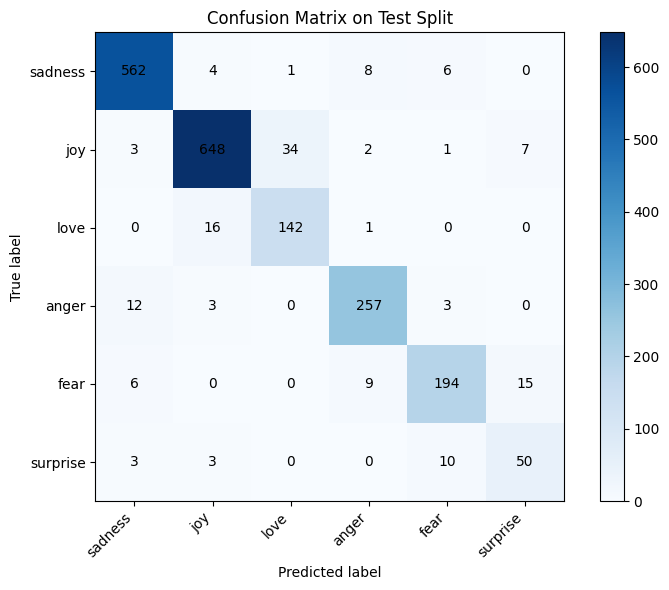

Saved: I:\Projects\Artificial_Intelligence_Engineer\homeworks\HW13\artifacts\confusion_matrix.png


In [56]:
# Строим матрицу ошибок на test-части.
cm = confusion_matrix(test_true_ids, test_pred_ids)

fig, ax = plt.subplots(figsize=(8, 6))
im = ax.imshow(cm, cmap="Blues")

ax.set_title("Confusion Matrix on Test Split")
ax.set_xlabel("Predicted label")
ax.set_ylabel("True label")
ax.set_xticks(range(len(label_names)))
ax.set_yticks(range(len(label_names)))
ax.set_xticklabels(label_names, rotation=45, ha="right")
ax.set_yticklabels(label_names)

for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        ax.text(j, i, cm[i, j], ha="center", va="center", color="black")

fig.colorbar(im, ax=ax)

plt.tight_layout()

confusion_matrix_path = artifacts_dir / "confusion_matrix.png"
plt.savefig(confusion_matrix_path, dpi=150, bbox_inches="tight")
plt.show()

print("Saved:", confusion_matrix_path.resolve())

In [57]:
# Показываем итоговый classification report.
report_dict = classification_report(
    test_true_ids,
    test_pred_ids,
    target_names=label_names,
    digits=4,
    output_dict=True,
)

classification_report_df = pd.DataFrame(report_dict).transpose()
classification_report_df

,precision,recall,f1-score,support
sadness,0.959044,0.967298,0.963153,581.0000
joy,0.961424,0.932374,0.946676,695.0000
love,0.802260,0.893082,0.845238,159.0000
anger,0.927798,0.934545,0.931159,275.0000
fear,0.906542,0.866071,0.885845,224.0000
surprise,0.694444,0.757576,0.724638,66.0000
accuracy,0.926500,0.926500,0.926500,0.9265
macro avg,0.875252,0.891824,0.882785,2000.0000
weighted avg,0.928499,0.926500,0.927125,2000.0000


In [58]:
# Показываем несколько правильных и ошибочных предсказаний.
correct_examples = predictions_df[predictions_df["true_label"] == predictions_df["pred_label"]].head(5)
error_examples = predictions_df[predictions_df["true_label"] != predictions_df["pred_label"]].head(10)

print("Примеры корректных предсказаний:")
display(correct_examples)

print("Примеры ошибок модели:")
display(error_examples)

Примеры корректных предсказаний:


,text,true_label,pred_label,confidence
0,im feeling rather rotten so im not very ambitious right now,sadness,sadness,0.997229
1,im updating my blog because i feel shitty,sadness,sadness,0.997474
2,i never make her separate from me because i don t ever want her to feel like i m ashamed with her,sadness,sadness,0.997553
3,i left with my bouquet of red and yellow tulips under my arm feeling slightly more optimistic than when i arrived,joy,joy,0.997214
4,i was feeling a little vain when i did this one,sadness,sadness,0.997477


Примеры ошибок модели:


,text,true_label,pred_label,confidence
10,i don t feel particularly agitated,fear,anger,0.900324
67,i feel a bit stressed even though all the things i have going on are fun,anger,sadness,0.630988
72,i am right handed however i play billiards left handed naturally so me trying to play right handed feels weird,surprise,fear,0.563146
86,i feel like i am in paradise kissing those sweet lips make me feel like i dive into a magical world of love,joy,love,0.802408
93,i was feeling weird the other day and it went away about minutes after i took my metformin,fear,surprise,0.532572
94,when a friend dropped a frog down my neck,anger,fear,0.772666
103,i feel agitated with myself that i did not foresee her frustrations earlier leading to the ending of our relationship,fear,anger,0.744935
108,i looked at mabel this morning i named my left breast mabel my right one is hazel and i feel this weird mixture of anger and loss valerie wrote less than a month after her diagnosis,fear,surprise,0.531753
111,i feel is he generous,love,joy,0.502141
131,im feeling generous today heres one more you may have already seen but is good for a chuckle,love,joy,0.752963


In [59]:
# Выводим ключевые итоговые метрики в компактном виде.
final_metrics = {
    "test_accuracy": test_metrics["eval_accuracy"],
    "test_f1_macro": test_metrics["eval_f1_macro"],
    "validation_accuracy": validation_metrics["eval_accuracy"],
    "validation_f1_macro": validation_metrics["eval_f1_macro"],
}

final_metrics

{'test_accuracy': 0.9265,
 'test_f1_macro': 0.882784956071483,
 'validation_accuracy': 0.938,
 'validation_f1_macro': 0.9123961964456546}

## 7. Краткие выводы

В работе выполнены все обязательные блоки HW13:
- sanity-check датасета;
- разбор токенизации;
- инференс готовой pretrained-модели;
- один сценарий fine-tuning;
- финальная оценка на `test`;
- сохранение обязательных артефактов.

Файлы `sample_predictions.csv` и `confusion_matrix.png` сохранены в папку `artifacts/`.